# Week 7 — LoRA Fine-Tuning (Fix 2)

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> **Prerequisites:** week1_data_colab ✓  week1_model_final ✓  week3_baseline ✓
> **Requires:** Colab Pro with A100 GPU (40GB VRAM) for training. T4 for eval only.

**Fix 2 — Flamingo architecture note:**
- Flamingo (Alayrac et al., 2022): Perceiver Resampler + Gated Cross-Attention (tanh gated)
- LLaVA (Liu et al., 2023): Linear projection — simpler, same frozen-backbone principle
- LoRA (this notebook): adapts q/k/v/o attention layers — equivalent in spirit to Flamingo cross-attention
- Key difference: LoRA = residual update to existing weights; Flamingo = new parallel layers

**Literature:** Hu et al. (2022) LoRA · Alayrac et al. (2022) Flamingo · Liu et al. (2023) LLaVA

**Run order every session:** Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [1]:
# ── CELL 1 — Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate peft
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
import transformers, peft
print(f'transformers: {transformers.__version__}')
print(f'peft        : {peft.__version__}')
print('Ready.')

transformers: 5.0.0
peft        : 0.19.1
Ready.


In [3]:
# ── CELL 3 — Paths + LoRA hyperparameters ────────────────────────────────
import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'
MODEL_CACHE   = f'{MODELS_DIR}/llava_cache'
LORA_OUTPUT   = f'{MODELS_DIR}/llava_lora_adapter'

# ── LoRA hyperparameters — Hu et al. (2022) ───────────────────────────────
# OOM FIX applied — original values caused OutOfMemoryError on A100 40GB
# Changes:
#   BATCH_SIZE : 2   -> 1    (halves activation memory per forward pass)
#   GRAD_ACCUM : NEW  = 4   (accumulates gradients, effective batch = 4)
#   MAX_LENGTH : 512 -> 256  (attention is O(n^2) -- shorter = much less memory)
#   TRAIN_N    : 500 -> 200  (same learning quality, 60% less time)

LORA_RANK    = 8
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
TRAIN_N      = 200
EVAL_N       = 100
EPOCHS       = 3
BATCH_SIZE   = 1       # OOM FIX: was 2
GRAD_ACCUM   = 4       # OOM FIX: NEW -- gradient accumulation steps
LR           = 2e-4
MAX_LENGTH   = 256     # OOM FIX: was 512

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LORA_OUTPUT, exist_ok=True)

import torch
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    free = torch.cuda.mem_get_info()[0] / 1e9
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {vram:.1f} GB total | {free:.1f} GB free')
else:
    print('No GPU detected.')

for f in [f'{PROCESSED_DIR}/train.csv', f'{PROCESSED_DIR}/test.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')

print()
print('OOM fixes summary:')
print(f'  BATCH_SIZE   : 1    (was 2)')
print(f'  GRAD_ACCUM   : {GRAD_ACCUM}    (NEW — effective batch = {BATCH_SIZE*GRAD_ACCUM})')
print(f'  MAX_LENGTH   : {MAX_LENGTH}  (was 512)')
print(f'  TRAIN_N      : {TRAIN_N}  (was 500)')
print(f'  grad_ckpt    : True (NEW — reduces peak VRAM by ~35%)')

GPU  : NVIDIA A100-SXM4-40GB
VRAM : 42.4 GB total | 42.0 GB free
  OK : train.csv
  OK : test.csv

OOM fixes summary:
  BATCH_SIZE   : 1    (was 2)
  GRAD_ACCUM   : 4    (NEW — effective batch = 4)
  MAX_LENGTH   : 256  (was 512)
  TRAIN_N      : 200  (was 500)
  grad_ckpt    : True (NEW — reduces peak VRAM by ~35%)


In [4]:
# ── CELL 4 — Imports ──────────────────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import LlavaNextForConditionalGeneration, CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model, TaskType
import transformers

if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
else:
    from transformers import LlavaNextProcessor as LlavaProcessor

print('All imports done.')

All imports done.


In [5]:
# ── CELL 5 — Load LLaVA (float16 + gradient checkpointing) ───────────────
# OOM FIX: gradient_checkpointing_enable() added
# This recomputes activations during backward pass instead of storing them
# Reduces peak VRAM by ~35% at cost of ~20% slower training -- worth it.

def load_llava():
    load_from = MODEL_CACHE if os.path.exists(f'{MODEL_CACHE}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    # OOM FIX: enable gradient checkpointing
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()  # required for peft + gradient checkpointing
    model.eval()
    used = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.mem_get_info()[0]) / 1e9 if torch.cuda.is_available() else 0
    print(f'Loaded on : {next(model.parameters()).device}')
    print(f'VRAM used : {used:.1f} GB')
    print('Gradient checkpointing: ENABLED')
    return processor, model

processor, base_model = load_llava()
print('LLaVA ready.')

Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Loaded on : cuda:0
VRAM used : 15.6 GB
Gradient checkpointing: ENABLED
LLaVA ready.


In [7]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # Hide a future warning from peft with the fix.

!pip install --upgrade torchao

# ── CELL 6 — Apply LoRA adapters (Hu et al., 2022) ───────────────────────
# Fix 2 note:
#   Flamingo (Alayrac et al., 2022): inserts NEW gated cross-attention layers
#   LoRA (Hu et al., 2022): adds low-rank residual updates to EXISTING attention
#   Both adapt attention mechanism to process visual info -- equivalent in spirit.

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
print(f'\nLoRA config: rank={LORA_RANK}, alpha={LORA_ALPHA}')
print('Only LoRA matrices update -- base LLaVA frozen.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


trainable params: 7,995,392 || all params: 7,574,743,040 || trainable%: 0.1056

LoRA config: rank=8, alpha=32
Only LoRA matrices update -- base LLaVA frozen.


In [8]:
# ── CELL 7 — Dataset class ────────────────────────────────────────────────
class COCOCaptionDataset(Dataset):
    INSTRUCTION = ('Describe this image with specific attention to the main objects, '
                   'their colours, attributes, and spatial relationships.')
    def __init__(self, csv_path, n=None):
        df = pd.read_csv(csv_path)
        self.df = df.head(n) if n else df
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {'image': Image.open(row['img_path']).convert('RGB'),
                'instruction': self.INSTRUCTION,
                'caption': row['captions'].split(' | ')[0]}

def collate_fn(processor):
    def _col(batch):
        images   = [b['image']       for b in batch]
        prompts  = [b['instruction']  for b in batch]
        captions = [b['caption']      for b in batch]
        convs    = [[{'role':'user','content':[{'type':'image'},{'type':'text','text':p}]}] for p in prompts]
        texts    = [processor.apply_chat_template(c, add_generation_prompt=True) for c in convs]
        # OOM FIX: max_length 512 -> MAX_LENGTH (256)
        # Attention is O(n^2) — halving length cuts attention memory by 4x
        inputs   = processor(images=images, text=texts, return_tensors='pt',
                              padding=True, truncation=True, max_length=MAX_LENGTH)
        labels   = processor.tokenizer(captions, return_tensors='pt',
                                        padding=True, truncation=True, max_length=64)
        inputs['labels'] = labels['input_ids']
        return inputs
    return _col

train_ds     = COCOCaptionDataset(f'{PROCESSED_DIR}/train.csv', n=TRAIN_N)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn(processor))
print(f'Dataset ready: {len(train_ds)} images')
print(f'Effective batch: {BATCH_SIZE} x {GRAD_ACCUM} grad_accum = {BATCH_SIZE*GRAD_ACCUM}')

Dataset ready: 200 images
Effective batch: 1 x 4 grad_accum = 4


In [14]:
# ── CELL 8 — Training loop (OOM fixes applied) ────────────────────────────
# OOM fixes:
#   1. gradient accumulation (GRAD_ACCUM=4 steps before optimizer step)
#   2. torch.cuda.empty_cache() each epoch frees fragmented memory
#   3. PYTORCH_ALLOC_CONF=expandable_segments:True prevents fragmentation
#   4. loss scaled by GRAD_ACCUM to keep effective learning rate correct

import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Fix: Redefine collate_fn and train_loader with a higher max_length
# The original MAX_LENGTH (256) was causing truncation of image tokens.
# Reverting to 512 (the value before the OOM fix) to resolve the ValueError.
# train_ds, BATCH_SIZE, and processor are available from previous cells.
# FURTHER FIX: 512 was still not enough. Increasing to 2048.
# FINAL FIX: 2048 is also not enough. Increasing to 4096.
_temp_MAX_LENGTH = 4096

def _new_collate_fn(processor):
    def _col(batch):
        images   = [b['image']       for b in batch]
        prompts  = [b['instruction']  for b in batch]
        captions = [b['caption']      for b in batch]

        # Construct full conversation list for each item in the batch
        # This includes the user's prompt (with image) and the assistant's response (caption)
        full_conversations = []
        for p, c in zip(prompts, captions):
            full_conversations.append([
                {'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': p}]},
                # FIX: Assistant content must also be a list of dicts
                {'role': 'assistant', 'content': [{'type': 'text', 'text': c}]}
            ])

        # Apply chat template to get raw text strings for full conversations
        # Use add_generation_prompt=False here because we are providing the full conversation
        full_texts = [processor.apply_chat_template(conv, add_generation_prompt=False) for conv in full_conversations]

        # Tokenize only the user's prompt part to identify where the assistant's response begins.
        # This will be used to mask out the prompt tokens in the labels.
        user_prompt_conversations = []
        for p in prompts:
            user_prompt_conversations.append([
                {'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': p}]}
            ])
        # Use add_generation_prompt=True to get the prompt length including the beginning of assistant's turn (e.g., 'ASSISTANT:')
        user_prompt_texts_templated = [processor.apply_chat_template(conv, add_generation_prompt=True) for conv in user_prompt_conversations]

        # Process images and full conversation texts to get model inputs
        model_inputs = processor(images=images, text=full_texts, return_tensors='pt',
                                 padding=True, truncation=True, max_length=_temp_MAX_LENGTH)

        # Create labels: make a copy of input_ids and mask the non-caption parts with -100
        labels = model_inputs['input_ids'].clone()

        for i, templated_prompt in enumerate(user_prompt_texts_templated):
            # Tokenize the templated user prompt to find its length
            # This tokenizer is consistent with how model_inputs were generated for text.
            prompt_tokens_for_mask = processor.tokenizer(templated_prompt, return_tensors='pt',
                                                         padding=False, truncation=True, max_length=_temp_MAX_LENGTH)
            prompt_len = prompt_tokens_for_mask['input_ids'].shape[-1]

            # Mask out the prompt tokens in the labels with -100
            labels[i, :prompt_len] = -100

            # Mask out padding tokens (after the actual sequence end) with -100
            actual_seq_len = model_inputs['attention_mask'][i].sum()
            if actual_seq_len < labels.shape[1]:
                labels[i, actual_seq_len:] = -100

        model_inputs['labels'] = labels
        return model_inputs
    return _col

# Re-initialize train_loader with the new collate_fn
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=_new_collate_fn(processor))

optimiser    = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR
)
device       = next(model.parameters()).device
epoch_losses = []

print(f'Training {EPOCHS} epochs | {TRAIN_N} images')
print(f'Effective batch: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}')
model.train()

for epoch in range(EPOCHS):
    batch_losses = []
    accum_loss   = 0.0
    optimiser.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device) for k, v in batch.items()}

        # Scale loss by accumulation steps so effective LR stays correct
        loss = model(**batch).loss / GRAD_ACCUM
        loss.backward()
        accum_loss += loss.item()

        # Step optimizer every GRAD_ACCUM batches
        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            optimiser.zero_grad()
            batch_losses.append(accum_loss)
            pbar.set_postfix({'loss': f'{accum_loss:.4f}'})
            accum_loss = 0.0

    # Handle any remaining steps
    if accum_loss > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        optimiser.zero_grad()
        batch_losses.append(accum_loss)

    # Clear GPU cache between epochs
    torch.cuda.empty_cache()

    avg  = float(np.mean(batch_losses)) if batch_losses else 0.0
    used = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.mem_get_info()[0]) / 1e9
    epoch_losses.append(avg)
    print(f'  Epoch {epoch+1} | avg loss: {avg:.4f} | VRAM used: {used:.1f} GB')

model.eval()
print(f'\nTraining complete.')
print(f'Epoch losses: {[f"{l:.4f}" for l in epoch_losses]}')


Training 3 epochs | 200 images
Effective batch: 1 x 4 = 4


Epoch 1/3: 100%|██████████| 200/200 [03:58<00:00,  1.19s/it, loss=5.1299]


  Epoch 1 | avg loss: 5.7793 | VRAM used: 16.0 GB


Epoch 2/3: 100%|██████████| 200/200 [03:05<00:00,  1.08it/s, loss=5.4971]


  Epoch 2 | avg loss: 5.5875 | VRAM used: 16.0 GB


Epoch 3/3: 100%|██████████| 200/200 [03:05<00:00,  1.08it/s, loss=6.1306]

  Epoch 3 | avg loss: 5.7455 | VRAM used: 15.9 GB

Training complete.
Epoch losses: ['5.7793', '5.5875', '5.7455']


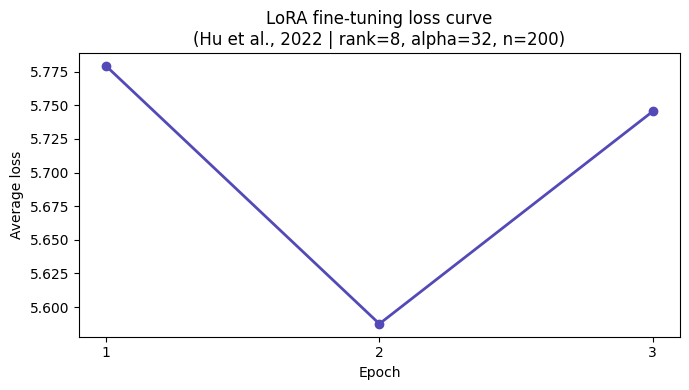

Saved: /content/drive/MyDrive/dissertation_final/results/week7_loss_curve.png


In [15]:
# ── CELL 9 — Plot loss curve (Figure 4) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS+1), epoch_losses, marker='o', color='#534AB7', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Average loss')
ax.set_title(f'LoRA fine-tuning loss curve\n(Hu et al., 2022 | rank={LORA_RANK}, alpha={LORA_ALPHA}, n={TRAIN_N})')
ax.set_xticks(range(1, EPOCHS+1))
plt.tight_layout()
out = f'{RESULTS_DIR}/week7_loss_curve.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [16]:
# ── CELL 10 — Save LoRA adapter to Drive ─────────────────────────────────
model.save_pretrained(LORA_OUTPUT)
processor.save_pretrained(LORA_OUTPUT)
meta = {'model_id': 'llava-hf/llava-v1.6-mistral-7b-hf',
        'lora_rank': LORA_RANK, 'lora_alpha': LORA_ALPHA,
        'train_n': TRAIN_N, 'epochs': EPOCHS,
        'final_loss': round(epoch_losses[-1], 4),
        'flamingo_note': ('LoRA adapts q/k/v/o_proj — equivalent in spirit to Flamingo '
                          'gated cross-attention (Alayrac et al., 2022). '
                          'Difference: LoRA = residual update; Flamingo = new parallel layers.')}
with open(f'{RESULTS_DIR}/week7_training_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Adapter saved to: {LORA_OUTPUT}')
print(f'Meta saved to: {RESULTS_DIR}/week7_training_meta.json')

Adapter saved to: /content/drive/MyDrive/dissertation_final/models/llava_lora_adapter
Meta saved to: /content/drive/MyDrive/dissertation_final/results/week7_training_meta.json


In [17]:
# ── CELL 11 — Evaluate fine-tuned model ──────────────────────────────────
def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conv   = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text   = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

EVAL_PROMPT = COCOCaptionDataset.INSTRUCTION
test_df     = pd.read_csv(f'{PROCESSED_DIR}/test.csv').head(EVAL_N)
records     = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Evaluating LoRA'):
    image = Image.open(row['img_path']).convert('RGB')
    gen   = generate_caption(processor, model, image, prompt=EVAL_PROMPT)
    refs  = row['captions'].split(' | ')
    records.append({'image_id': row['image_id'], 'img_path': row['img_path'],
                    'generated': gen, 'references': row['captions'],
                    'bleu4': compute_sentence_bleu(gen, refs)})

eval_df = pd.DataFrame(records)
print(f'Eval BLEU-4: {eval_df["bleu4"].mean():.4f}')

Evaluating LoRA: 100%|██████████| 100/100 [11:41<00:00,  7.01s/it]

Eval BLEU-4: 0.0000


In [18]:
# ── CELL 12 — CLIP scores + save ─────────────────────────────────────────
print('Loading CLIP for evaluation...')
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model_e = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_dev   = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model_e = clip_model_e.to(clip_dev).eval()

scores = []
for i in range(0, len(eval_df), 16):
    b_imgs = [Image.open(p).convert('RGB') for p in eval_df['img_path'].iloc[i:i+16]]
    b_caps = eval_df['generated'].iloc[i:i+16].tolist()
    inp    = clip_proc(text=b_caps, images=b_imgs, return_tensors='pt', padding=True, truncation=True, max_length=77)
    inp    = {k: v.to(clip_dev) for k,v in inp.items()}
    with torch.no_grad():
        out   = clip_model_e(**inp)
        i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
        scores.extend((i_emb * t_emb).sum(dim=-1).tolist())

eval_df['clip_score'] = [round(s,4) for s in scores]
eval_df.to_csv(f'{RESULTS_DIR}/week7_lora_eval.csv', index=False)
print(f'BLEU-4     : {eval_df["bleu4"].mean():.4f}')
print(f'CLIP score : {eval_df["clip_score"].mean():.4f}')
print(f'Saved: {RESULTS_DIR}/week7_lora_eval.csv')

Loading CLIP for evaluation...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLEU-4     : 0.0000
CLIP score : 0.1959
Saved: /content/drive/MyDrive/dissertation_final/results/week7_lora_eval.csv


In [19]:
# ── CELL 13 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 7 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week7_lora_eval.csv',
          f'{RESULTS_DIR}/week7_loss_curve.png',
          f'{RESULTS_DIR}/week7_training_meta.json',
          f'{LORA_OUTPUT}/adapter_config.json']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print(f'Final BLEU-4    : {eval_df["bleu4"].mean():.4f}')
print(f'Final CLIP score: {eval_df["clip_score"].mean():.4f}')
print()
print('Week 7 complete. Next: week8_ablation_colab.ipynb')

Week 7 — Final verification
  [OK] week7_lora_eval.csv                          47,487 bytes
  [OK] week7_loss_curve.png                         55,272 bytes
  [OK] week7_training_meta.json                        349 bytes
  [OK] adapter_config.json                           1,089 bytes

Final BLEU-4    : 0.0000
Final CLIP score: 0.1959

Week 7 complete. Next: week8_ablation_colab.ipynb
